# Composition audit — properties of the 50K selection

The artifact under audit is `data/composition/` (built by `scripts/compose_target.py`, SPEC d32/d33): `selection.parquet` — the 50K natural core — plus `order_sheet.parquet` (the deficits the generation lane must fill) and `summary.md` (the build log).

Five questions, one section each:

1. **Recipe conformance** — do the slices match the d32 split?
2. **Source mix** — who supplies the rows; does any source over-concentrate; do the dark-forest champion caps hold?
3. **Floor outcomes** — which evidence floors were satisfied vs starved (the starved ones ARE the order sheet).
4. **Coverage terrain** — the SPEC d31 grids restricted to the selected 50K: what the composition actually bought (compare with `dataset_audit.ipynb`, which maps the full catalog).
5. **Router signals** — how the scalar signals distribute per slice.

Slices: **A** span type-targeted (48%), **B** span no-preference (12%), **C** stat strata / zero-span bands (20%), **D** dark forest — feature-blind champion draws (20%, per-champion cap 50%). Lanes: `qrels` (labelable now) vs `deferred`.

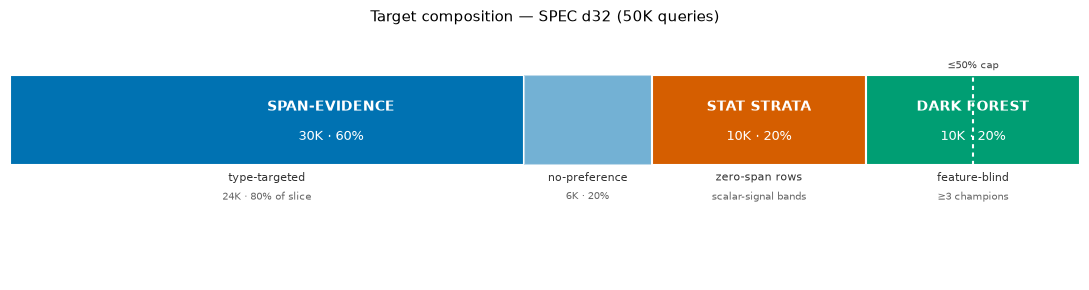

In [1]:
from report_charts import target_composition

target = target_composition()

Reading guide:

- **Conformance is exact by construction** (`TargetComposition._assert_invariants`); the table exists for the record, not for suspense.
- **Floor credit here is raw row counts** (rows crediting each floor via their `floors` list), not the ambiguity-discounted evidence amounts the fill optimized — so `credit` in the order sheet and row counts here legitimately differ.
- **Coverage cells** use the same equal-weight dominance as the dataset audit: a cell's label is the debiased dominant source *within the selection*.

In [27]:
# Evidence assembly — all inputs are local artifacts (data/composition/*,
# data/feature_table/catalog.parquet, data/profiles/*.json); no network.
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from tqdm.auto import tqdm

from composition import Recipe, TargetComposition
from query_taxonomy.features import CorpusFeatures, FeatureExtractor
from query_taxonomy.reporting import CorpusReport
from report_charts import coverage_map_grid, domain_share_bar, feature_donut

PROFILES = Path("data/profiles")

SLICE_NAMES = {
    "A": "span type-targeted",
    "B": "span no-preference",
    "C": "stat strata",
    "D": "dark forest",
}

SIGNALS = (
    "length.length_words",
    "natural_language_signal.natural_language_share",
    "stopword_ratio.stopword_ratio",
    "syntactic_depth.nesting_depth",
    "syntactic_depth.statement_count",
    "coordination.widest_list_size",
    "morphology.word_variation_share",
)


class CompositionAudit:
    """Properties of the composed selection: recipe conformance, source
    concentration, floor outcomes, and the coverage terrain the 50K
    actually bought."""

    COMPOSITION_PROFILE = PROFILES / "composition.json"

    def __init__(
        self,
        selection: pd.DataFrame,
        order_sheet: pd.DataFrame,
        catalog: pd.DataFrame,
        recipe: Recipe,
    ) -> None:
        self.selection = selection
        self.order_sheet = order_sheet
        self.catalog = catalog
        self.recipe = recipe
        self.joined = selection[
            ["dataset", "query_id", "slice", "label_lane"]
        ].merge(
            catalog, on=["dataset", "query_id"], how="left",
            validate="one_to_one",
        )

    def slice_conformance(self) -> pd.DataFrame:
        targets = {
            "A": self.recipe.span_target_rows,
            "B": self.recipe.no_preference_rows,
            "C": self.recipe.stat_strata_rows,
            "D": self.recipe.dark_forest_rows,
        }
        actual = self.selection["slice"].value_counts()
        return pd.DataFrame({
            "slice": list(targets),
            "name": [SLICE_NAMES[s] for s in targets],
            "target_rows": list(targets.values()),
            "actual_rows": [int(actual.get(s, 0)) for s in targets],
        }).assign(delta=lambda f: f.actual_rows - f.target_rows)

    def source_mix(self) -> pd.DataFrame:
        mix = self.selection.pivot_table(
            index="dataset", columns="slice", aggfunc="size", fill_value=0
        )
        mix["total"] = mix.sum(axis=1)
        mix["share"] = (mix["total"] / len(self.selection)).map("{:.1%}".format)
        return mix.sort_values("total", ascending=False)

    def concentration(self) -> pd.DataFrame:
        rows = []
        for slice_, group in self.selection.groupby("slice"):
            counts = group["dataset"].value_counts()
            rows.append({
                "slice": slice_,
                "name": SLICE_NAMES[slice_],
                "rows": len(group),
                "sources": counts.size,
                "top_source": counts.index[0],
                "top_share": f"{counts.iloc[0] / len(group):.1%}",
            })
        return pd.DataFrame(rows)

    def champion_caps(self) -> pd.DataFrame:
        dark = self.selection[self.selection["slice"] == "D"]
        counts = dark["dataset"].value_counts()
        cap = self.recipe.floor_rules.cap_frac
        return pd.DataFrame({
            "champion": list(self.recipe.champions),
            "target_share": list(self.recipe.champions.values()),
            "actual_share": [
                counts.get(c, 0) / len(dark) for c in self.recipe.champions
            ],
        }).assign(within_cap=lambda f: f.actual_share <= cap)

    def lanes(self) -> pd.DataFrame:
        table = self.selection.pivot_table(
            index="slice", columns="label_lane", aggfunc="size", fill_value=0
        )
        table["qrels_share"] = (
            table["qrels"] / table.sum(axis=1)
        ).map("{:.0%}".format)
        return table

    def floor_credit(self) -> pd.DataFrame:
        """Rows crediting each floor (exploded from `floors`), by slice —
        raw row counts, not the discounted evidence the fill used."""
        exploded = self.selection.explode("floors").dropna(subset=["floors"])
        return exploded.pivot_table(
            index="floors", columns="slice", aggfunc="size", fill_value=0
        ).sort_index()

    def deficits(self) -> pd.DataFrame:
        return self.order_sheet.sort_values(
            "missing", ascending=False, ignore_index=True
        )

    def coverage(self):
        return coverage_map_grid(self.joined)

    def signal_profile(self) -> pd.DataFrame:
        present = [s for s in SIGNALS if s in self.joined.columns]
        return self.joined.groupby("slice")[present].median().T.round(2)

    def profile(self) -> CorpusFeatures:
        """CorpusFeatures of the WHOLE selection — extracted once (~40s of
        regex + spaCy over the 50K texts) and cached beside the registry
        profiles as composition.json; every later call loads the JSON."""
        if self.COMPOSITION_PROFILE.exists():
            return CorpusFeatures.model_validate_json(
                self.COMPOSITION_PROFILE.read_text()
            )
        texts = tqdm(
            self.selection["query"].tolist(),
            desc=f"profile composition (n={len(self.selection):,})",
            unit="query",
        )
        profile = FeatureExtractor(engines=None).extract(texts)
        self.COMPOSITION_PROFILE.write_text(profile.model_dump_json())
        return profile

    def show(self) -> None:
        """The composed dataset as one corpus: selection-scoped counts,
        then the same identity charts the per-dataset audits use — so the
        50K reads side by side with any source in dataset_audit.ipynb."""
        report = CorpusReport(self.profile())
        per_slice = self.selection["slice"].value_counts()
        lanes = self.selection["label_lane"].value_counts()
        print(
            f"{len(self.selection):,} rows from "
            f"{self.selection['dataset'].nunique()} datasets   slices: "
            + "  ".join(f"{s}={per_slice.get(s, 0):,}" for s in SLICE_NAMES)
        )
        print(
            "lanes: "
            + "  ".join(f"{lane}={count:,}" for lane, count in lanes.items())
        )
        credited = (
            self.selection.explode("floors")["floors"].value_counts().head(8)
        )
        print(f"floors credited (top {len(credited)} by rows):")
        for floor, count in credited.items():
            print(f"  {floor}: {count:,}")
        feature_donut(
            report, title="composition — feature spans"
        ).tight_layout()
        plt.show()
        domain_share_bar(
            report, title="composition — domain query share"
        ).tight_layout()
        plt.show()

    def show_samples(self, n: int = 5, *, seed: int = 0) -> None:
        """n seeded random rows per source — the eyeball check the summary
        tables can't give: does each dataset's contribution read like its
        reputation? Texts are whitespace-collapsed and clipped to one line."""
        samples = self.selection.groupby("dataset").sample(
            n=n, random_state=seed
        )
        for name, group in samples.groupby("dataset"):
            print(name)
            for _, row in group.iterrows():
                text = " ".join(str(row["query"]).split())[:110]
                print(f"  [{row['slice']}·{row['label_lane']}] {text}")

    def integrity(self) -> pd.Series:
        feature_probe = next(c for c in self.catalog.columns if "." in c)
        return pd.Series({
            "rows": len(self.selection),
            "unique (dataset, query_id)": len(
                self.selection.drop_duplicates(["dataset", "query_id"])
            ),
            "catalog join misses": int(
                self.joined[feature_probe].isna().sum()
            ),
            "duplicate texts": int(
                self.selection["query"].duplicated().sum()
            ),
            "empty texts": int(
                (self.selection["query"].str.strip() == "").sum()
            ),
        })

In [28]:
composition = TargetComposition()
audit = CompositionAudit(
    selection=pd.read_parquet(composition.selection_path),
    order_sheet=pd.read_parquet(composition.order_sheet_path),
    catalog=pd.read_parquet("data/feature_table/catalog.parquet"),
    recipe=Recipe(),
)
audit.integrity()

rows                          50000
unique (dataset, query_id)    50000
catalog join misses               0
duplicate texts                 339
empty texts                      13
dtype: int64

50,000 rows from 21 datasets   slices: A=24,000  B=6,000  C=10,000  D=10,000
lanes: qrels=34,256  deferred=15,744
floors credited (top 8 by rows):
  id:number: 16,251
  marker:comparative: 5,603
  marker:negation: 5,501
  natural_language_share:0.4+ sentence: 5,040
  nesting_depth:2-3: 4,983
  id:tech: 4,547
  length_words:3-6: 4,073
  logical:math_expression: 3,915


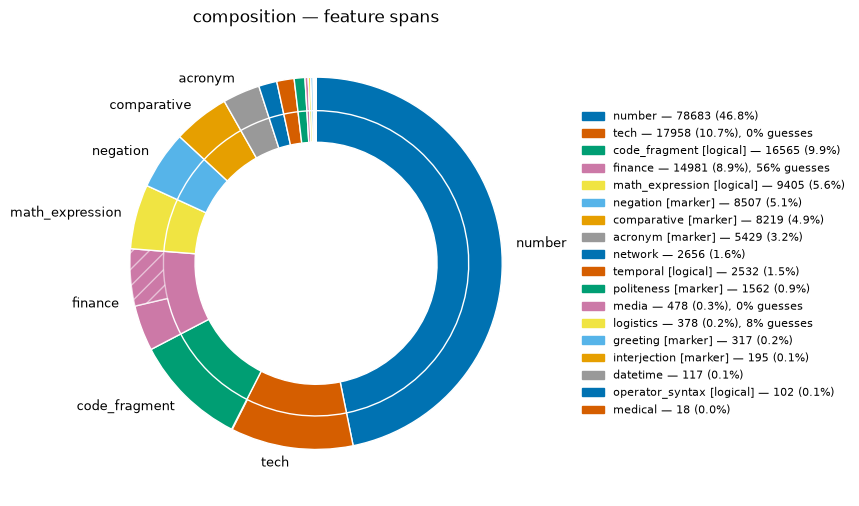

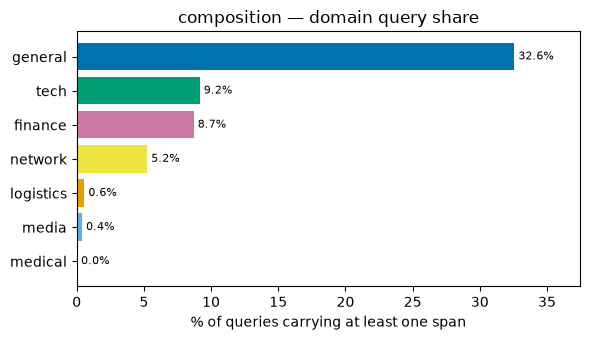

In [29]:
audit.show()

### Eyeball check — 5 random rows per source

Seeded sample straight from the selection (`[slice·lane] text`): does each dataset's contribution read like its reputation? Change `seed=` for a fresh draw.

In [30]:
audit.show_samples()

beir-nfcorpus
  [C·qrels] betel nuts
  [C·qrels] hearing
  [A·qrels] EPIC Study
  [C·qrels] Is apple cider vinegar good for you?
  [C·qrels] shelf life
bright-aops
  [A·qrels] Triangle $ABC$ is inscribed in circle $\omega$. Points $P$ and $Q$ are on side $\overline{AB}$ with $AP<AQ$. R
  [A·qrels] Let $P$ be a point on the circle circumscribing square $ABCD$ that satisfies $PA \cdot PC = 56$ and $PB \cdot 
  [A·qrels] A rectangular floor measures $a$ by $b$ feet, where $a$ and $b$ are positive integers with $b > a$. An artist 
  [B·qrels] Let $D(n)$ denote the number of ways of writing the positive integer $n$ as a product $n = f_1\cdot f_2\cdots 
  [A·qrels] In rectangle $ABCD,$ $AB=6$ and $BC=3$. Point $E$ between $B$ and $C$, and point $F$ between $E$ and $C$ are s
bright-leetcode
  [A·qrels] You are given a 2D integer array `grid` of size `m x n`, where each cell contains a positive integer. A **corn
  [A·qrels] You are given a **0-indexed** integer array `nums`, where `nums[i]` re

## Recipe conformance

In [4]:
audit.slice_conformance()

,slice,name,target_rows,actual_rows,delta
0,A,span type-targeted,24000,24000,0
1,B,span no-preference,6000,6000,0
2,C,stat strata,10000,10000,0
3,D,dark forest,10000,10000,0


**Finding (draft):** all four deltas are 0 — 24K/6K/10K/10K exactly, as asserted at build time. The interesting conformance story is not the row counts but the floors (below): hitting the slice size while starving 10 of 19 A-floors is precisely what "natural core first, generation fills the rest" means.

_Edit this cell to record final observations._

## Source mix & concentration

In [5]:
audit.source_mix()

slice,A,B,C,D,total,share
dataset,,,,,,
orcas,8323,2351,70,5000,15744,31.5%
msmarco-passage-dev,4929,1108,6641,3000,15678,31.4%
rarb-math,4971,1183,122,0,6276,12.6%
crumb-code-retrieval,2885,675,105,0,3665,7.3%
crumb-legal-qa,290,60,1200,2000,3550,7.1%
rarb-code,875,190,52,0,1117,2.2%
quest,631,176,121,0,928,1.9%
miracl-en-dev,96,25,409,0,530,1.1%
crumb-set-operation-entity-retrieval,180,36,207,0,423,0.8%


In [6]:
display(audit.concentration())
audit.champion_caps()

,slice,name,rows,sources,top_source,top_share
0,A,span type-targeted,24000,21,orcas,34.7%
1,B,span no-preference,6000,20,orcas,39.2%
2,C,stat strata,10000,18,msmarco-passage-dev,66.4%
3,D,dark forest,10000,3,orcas,50.0%


,champion,target_share,actual_share,within_cap
0,orcas,0.5,0.5,True
1,msmarco-passage-dev,0.3,0.3,True
2,crumb-legal-qa,0.2,0.2,True


**Finding (draft):** slice A leans on four suppliers — orcas (~8.3K, ~35%), rarb-math (~5.0K), msmarco (~4.9K), crumb-code-retrieval (~2.9K) — consistent with who owns span mass in the dataset audit. Slice D lands exactly on the champion targets (orcas 50% / msmarco 30% / crumb-legal-qa 20%), all within the 50% cap. Watch item: rarb-math + rarb-code + crumb-code together are ~7.9K of slice A — the math/code flavor is a third of the type-targeted slice; if that reads as over-representation, the lever is the per-floor cap, not the slice shares.

_Edit this cell to record final observations._

## Label lanes

In [7]:
audit.lanes()

label_lane,deferred,qrels,qrels_share
slice,,,
A,8323,15677,65%
B,2351,3649,61%
C,70,9930,99%
D,5000,5000,50%


**Finding (draft):** 34,256 rows (~69%) sit in the qrels lane and are labelable now; the 15,744 deferred rows are dominated by orcas (QC grounding — clicks, not qrels). The labeling pilots (d30 R1/R2) should draw from the qrels lane only.

_Edit this cell to record final observations._

## Floor outcomes & the order sheet

`floor_credit()` counts selected rows crediting each floor; `deficits()` is the order sheet — `missing` is denominated in discounted evidence, and every `exhausted` row is a generation-lane work order.

In [8]:
audit.floor_credit()

slice,A,B,C
floors,,,
id:datetime,3,0,0
id:finance,2143,533,0
id:logistics,213,49,0
id:media,165,33,0
id:medical,10,3,0
id:network,2041,556,0
id:number,12995,3256,0
id:shape_guess,1712,406,0
id:tech,3655,892,0


In [9]:
audit.deficits()

,slice,floor,amount,credit,missing,reason
0,A,id:datetime,1000.0,3.00,997.00,exhausted
1,A,id:medical,1000.0,7.50,992.50,exhausted
2,A,logical:operator_syntax,1000.0,35.00,965.00,exhausted
3,A,id:logistics,1000.0,109.50,890.50,exhausted
4,A,id:media,1000.0,124.25,875.75,exhausted
5,A,marker:greeting,1000.0,139.00,861.00,exhausted
6,A,marker:interjection,1000.0,147.00,853.00,exhausted
7,A,id:network,1000.0,566.25,433.75,capped
8,C,length_words:60+,714.0,288.00,426.00,exhausted
9,A,id:shape_guess,1000.0,864.25,135.75,exhausted


**Finding (draft):** 11 floors under target — 10 in slice A plus `length_words:60+` in C. The starvation ranking: `id:datetime` (3/1000 — relative temporal went to logical:temporal, absolute datetimes are simply rare in queries), `id:medical` (7.5), `logical:operator_syntax` (35 — matches the d20 research: operators are rare-but-real), `marker:greeting` (139), `marker:interjection` (147), `id:logistics` (109.5), `id:media` (124.25), `id:shape_guess` (864), `marker:politeness` (986 — nearly closed). `id:network` is the one `capped` row: supply exists but the ≤50%-per-dataset rule blocks it — a diversification gap, not a scarcity gap; generation for it should target *new* sources' shapes, not more of the same.

_Edit this cell to record final observations._

## Coverage terrain of the composed 50K

Same d31 grids as `dataset_audit.ipynb`, restricted to selected rows — what the composition actually bought.

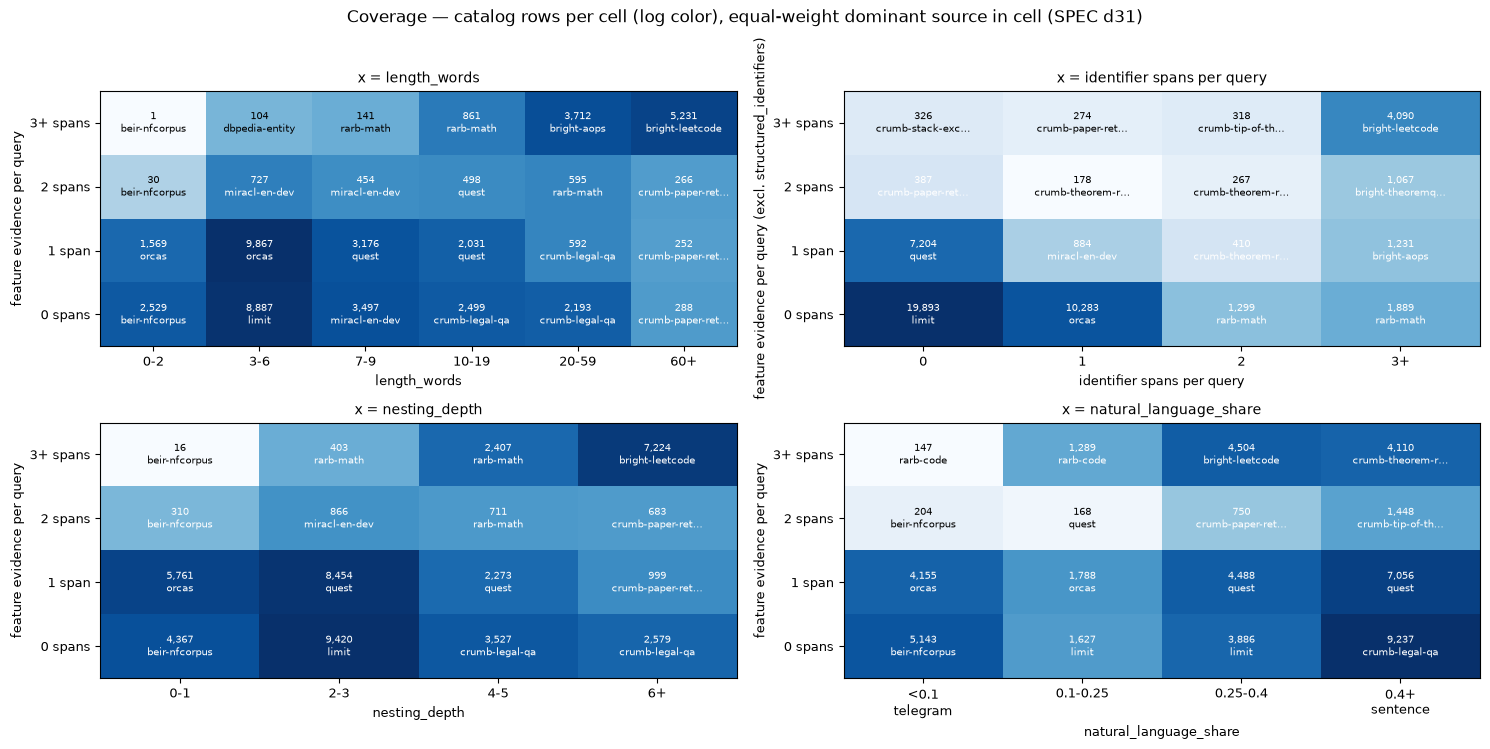

In [10]:
audit.coverage()
plt.show()

**Finding (draft):** compare against the full-catalog terrain in the dataset audit: the bottom-heavy zero-span mass (~86% of the catalog) is compressed to the C+D budget, and the upper span-dense rows are proportionally far heavier — that inversion is the point of the recipe. Scarce cells (short × 3+ spans) were take-everything territory, so their counts here should equal the catalog's.

_Edit this cell to record final observations._

## Router signals by slice

In [11]:
audit.signal_profile()

slice,A,B,C,D
length.length_words,9.00,8.00,7.00,5.00
natural_language_signal.natural_language_share,0.36,0.36,0.40,0.33
stopword_ratio.stopword_ratio,0.29,0.27,0.40,0.33
syntactic_depth.nesting_depth,3.00,3.00,3.00,2.00
syntactic_depth.statement_count,1.00,1.00,1.00,1.00
coordination.widest_list_size,0.00,0.00,0.00,0.00
morphology.word_variation_share,0.16,0.16,0.17,0.12


**Finding (draft):** sanity expectations — C (stat strata) and D (dark forest) should sit near web-query medians (short, low nesting); A should skew longer and evidence-denser (math/code word problems); B sits between, being an unweighted draw over span rows. Signals must be read jointly per the four-signals doctrine: `nesting_depth` is only meaningful where `natural_language_share` indicates natural language.

_Edit this cell to record final observations._

In [ ]:
audit.selection

,dataset,query_id,checkable,slice,label_lane,floors,query
0,beir-nfcorpus,PLAIN-1018,True,A,qrels,"[id:shape_guess, marker:acronym]",DHA
1,beir-nfcorpus,PLAIN-1088,True,A,qrels,"[id:shape_guess, marker:acronym]",ECMO
2,beir-nfcorpus,PLAIN-112,True,A,qrels,"[id:shape_guess, marker:acronym]",Food Dyes and ADHD
3,beir-nfcorpus,PLAIN-1320,True,A,qrels,"[id:shape_guess, marker:acronym]",Harvard Physicians’ Study II
4,beir-nfcorpus,PLAIN-1398,True,A,qrels,"[id:number, id:shape_guess, marker:acronym]",IGF-1
...,...,...,...,...,...,...,...
49995,orcas,9988728,False,D,deferred,[],features of powerpoint
49996,orcas,9992019,False,D,deferred,[],zip code looku
49997,orcas,9993059,False,D,deferred,[],equifax member sign in canada
49998,orcas,9994522,False,D,deferred,[],southshore ky
